In [ ]:
import optuna
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
from optuna.visualization import plot_optimization_history

from utils.visualization import plot_correlation_with_target, plot_heatmap
from utils.tuning import tune_hyperparameters
from utils.config import load_config

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
config = load_config()

### Research

In [3]:
train_data_25 = pd.read_csv(f"data/train/fbm_25x100000.csv")

In [4]:
train_data_25.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,hurst
0,0.630156,0.655636,0.466815,0.513658,0.575464,0.482970,0.663228,0.463617,0.270343,0.000000,...,0.672061,0.702047,0.565619,0.977708,0.896859,1.000000,0.780378,0.634554,0.917422,0.244
1,0.000000,0.025500,0.123266,0.150564,0.168969,0.189473,0.204494,0.246022,0.341025,0.386558,...,0.703977,0.724446,0.779338,0.788316,0.785435,0.841150,0.891719,0.931595,1.000000,0.956
2,0.591995,0.614123,0.650900,0.889391,0.767650,1.000000,0.835898,0.651895,0.510849,0.261494,...,0.425772,0.186445,0.423948,0.190810,0.182396,0.320916,0.039390,0.093267,0.000000,0.379
3,0.507680,0.601464,0.450199,0.468034,0.511136,0.433148,0.299615,0.636246,0.538522,0.360179,...,0.878296,0.640413,0.647065,0.443229,0.278670,0.273502,0.139782,0.157063,0.000000,0.412
4,1.000000,0.659442,0.568192,0.367056,0.195554,0.027031,0.000000,0.151213,0.471716,0.213313,...,0.496618,0.477921,0.369196,0.157910,0.130896,0.268328,0.312351,0.197147,0.170139,0.744


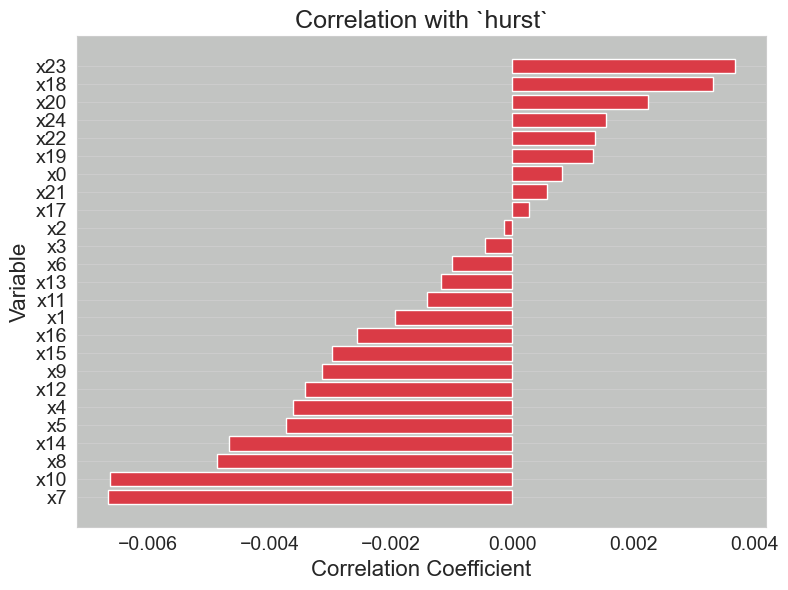

In [5]:
plot_correlation_with_target(train_data_25, 'hurst', plot_size=(8, 6))

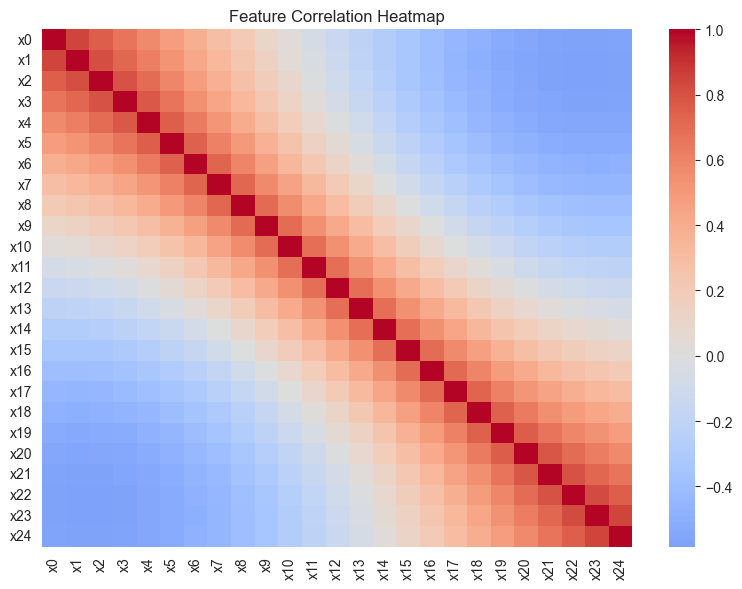

In [6]:
plot_heatmap(train_data_25.drop(columns=['hurst']), plot_size=(8, 6))

In [7]:
train_data_50 = pd.read_csv(f"data/train/fbm_50x100000.csv")

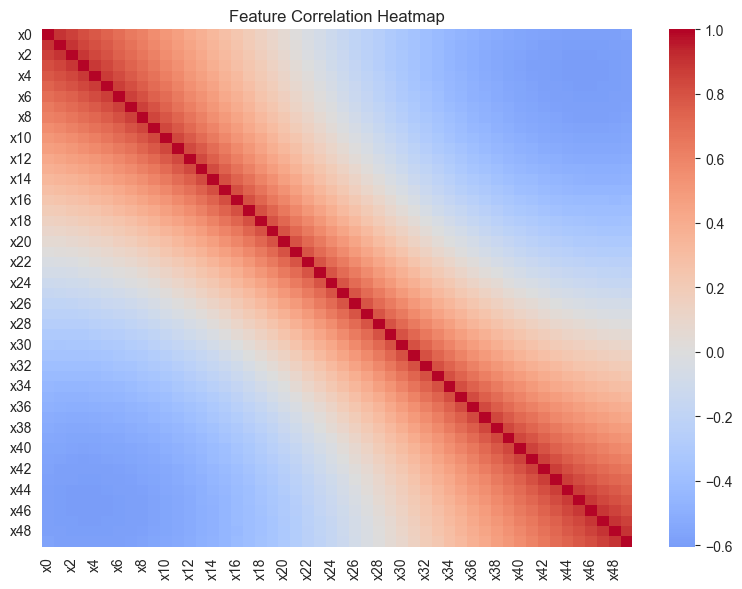

In [8]:
plot_heatmap(train_data_50.drop(columns=['hurst']), plot_size=(8, 6))

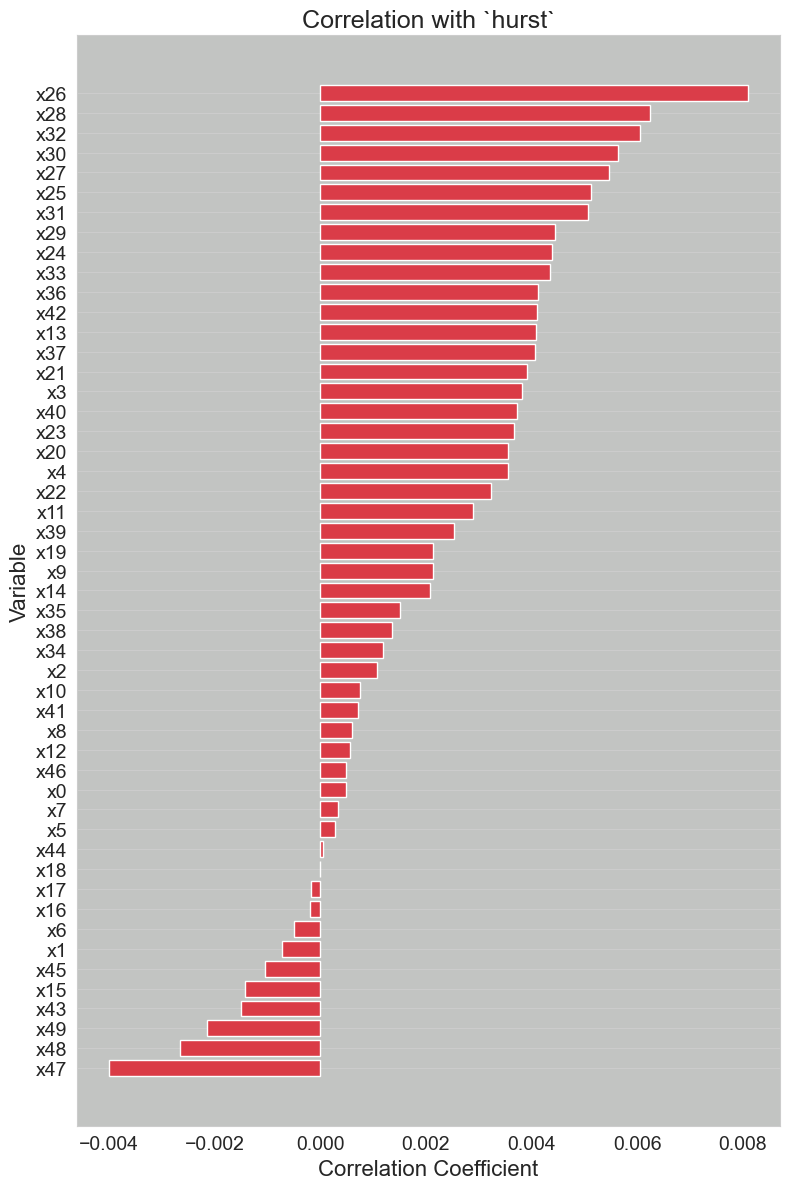

In [9]:
plot_correlation_with_target(train_data_50, 'hurst', plot_size=(8, 12))

In [10]:
train_data_100 = pd.read_csv(f"data/train/fbm_100x100000.csv")

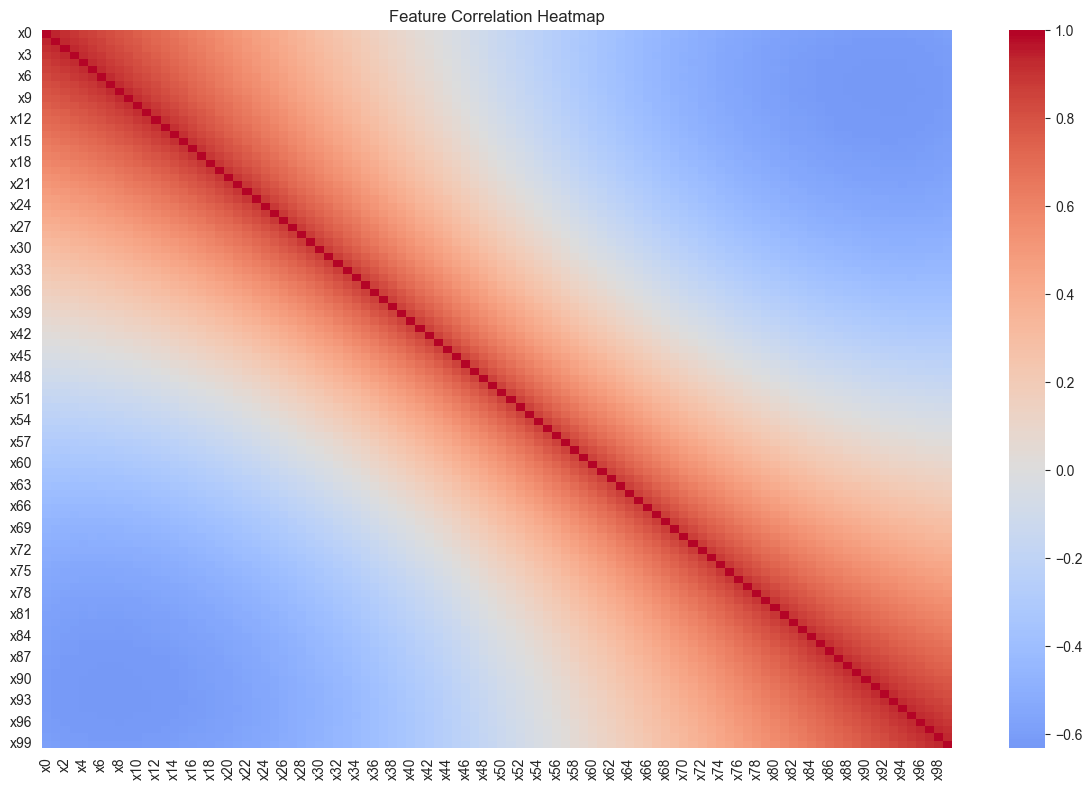

In [11]:
plot_heatmap(train_data_100.drop(columns=['hurst']), plot_size=(12, 8))

- Ярко-красная диагональ: Вызвана непрерывностью процесса. Соседние во времени точки почти идентичны, поэтому их корреляция стремится к +1.
- Синие углы (отрицательная корреляция): Это самый важный результат. Он показывает, что в среднем удаленные точки (начало и конец процесса) движутся в противоположных направлениях. Это происходит потому, что:
    - Процессы с H < 0.5 (анти-персистентные) имеют сильную тенденцию "возвращаться к среднему", что создает сильную отрицательную корреляцию.
    - Процессы с H > 0.5 (персистентные) имеют слабую тенденцию "следовать тренду", что создает слабую положительную корреляцию.

Итоговый вид: При усреднении всех процессов, сильный отрицательный эффект от анти-персистентных симуляций "перевешивает" слабый положительный эффект от персистентных. В результате итоговая усредненная матрица демонстрирует отрицательную корреляцию в углах, окрашивая их в синий цвет.

Именно поэтому в вашем предыдущем вопросе Ридж-регрессия показывала все лучшие результаты с увеличением параметра регуляризации alpha. Когда вы используете все эти x_i как признаки для модели, модель сталкивается с огромной проблемой: как распределить вес между x_5, x_6 и x_7, если они несут почти идентичную информацию?
Без сильной регуляризации коэффициенты модели становятся нестабильными и неоправданно большими. Большой alpha в Ридж-регрессии принудительно "сглаживает" и уменьшает эти коэффициенты, делая модель более робастной, что и приводило к улучшению метрик.

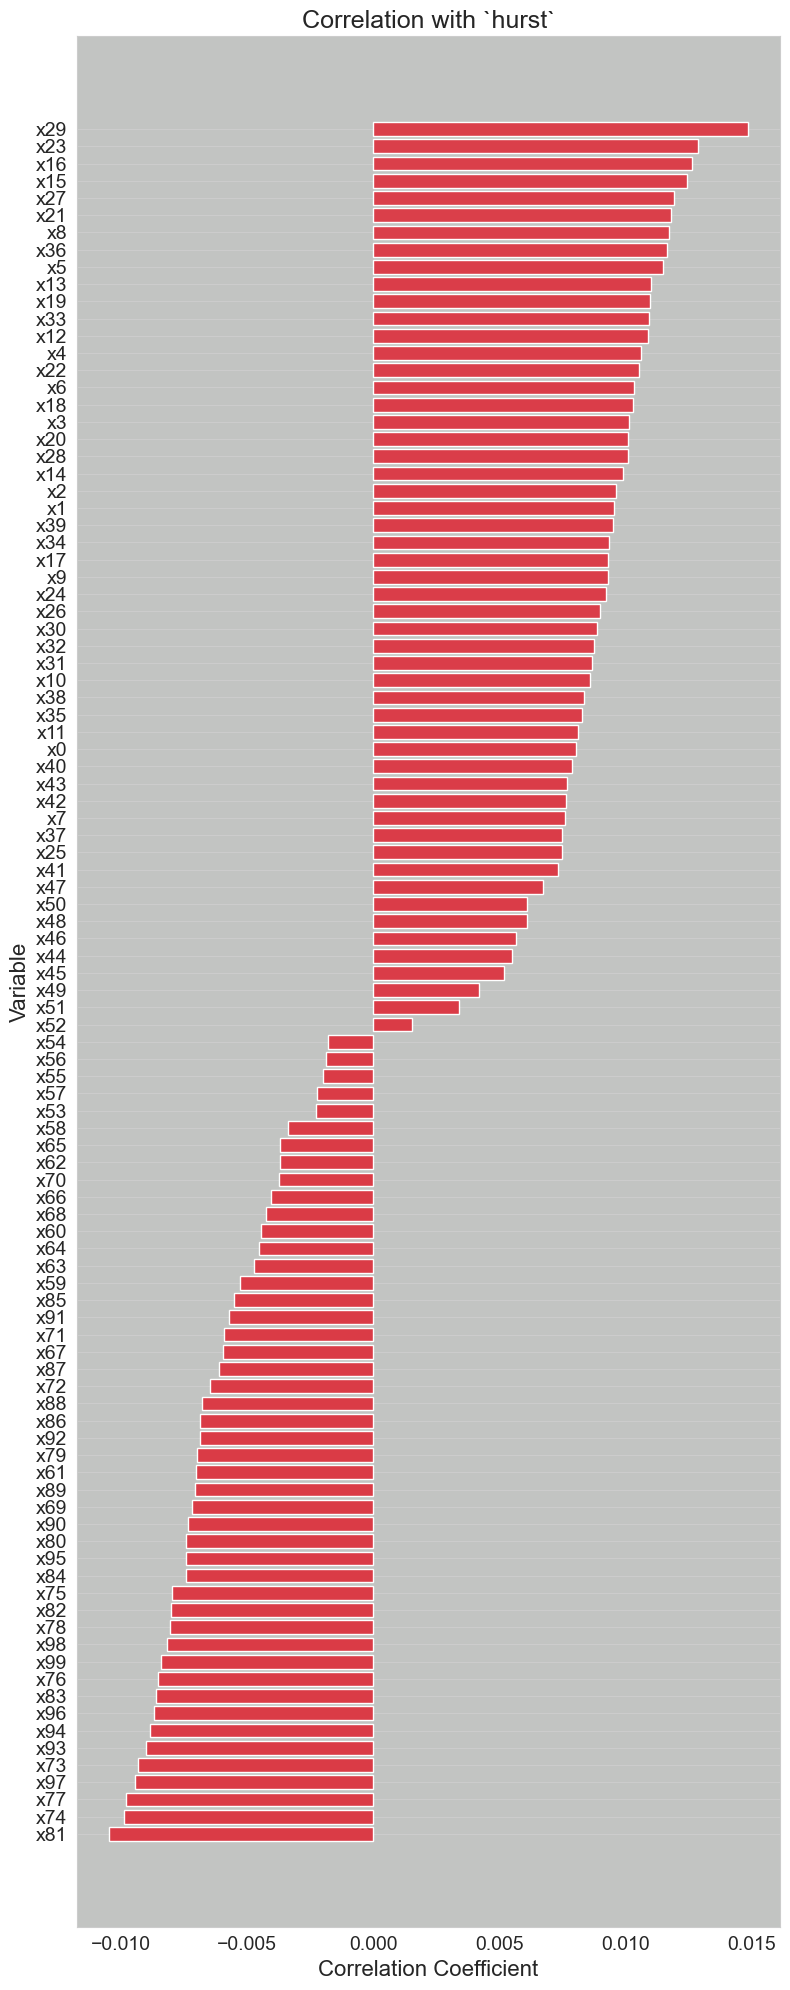

In [12]:
plot_correlation_with_target(train_data_100, 'hurst', plot_size=(8, 20))